<a href="https://colab.research.google.com/github/JulianSantos-LATAMAI/ECON-5200/blob/main/Lab_15/%5BLab_15%5D_The_Architecture_of_Generalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

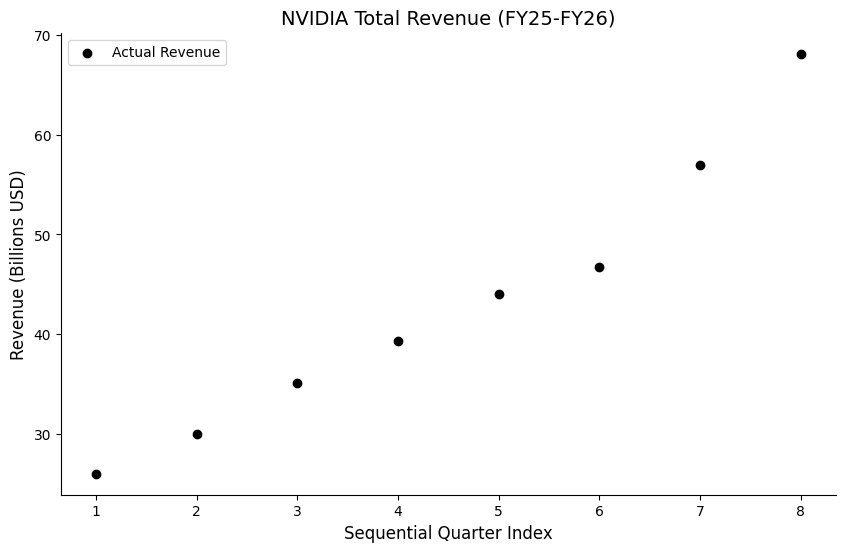

,Time_Index,Total_Revenue_Billions
0,1,26.04
1,2,30.04
2,3,35.10
3,4,39.33
4,5,44.06


In [2]:
## Data injection and EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

##Dataset

data = {
    'Time_Index': np.array([1, 2, 3, 4, 5, 6, 7, 8]),
    'Total_Revenue_Billions': np.array([26.04, 30.04, 35.10, 39.33, 44.06, 46.74, 57.00, 68.10])
}
df = pd.DataFrame(data)

X = df[['Time_Index']]
y = df['Total_Revenue_Billions']

# Visual EDA
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.title('NVIDIA Total Revenue (FY25-FY26)', fontsize=14)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.show()

df.head()

Linear Training MSE (High Bias): 7.91


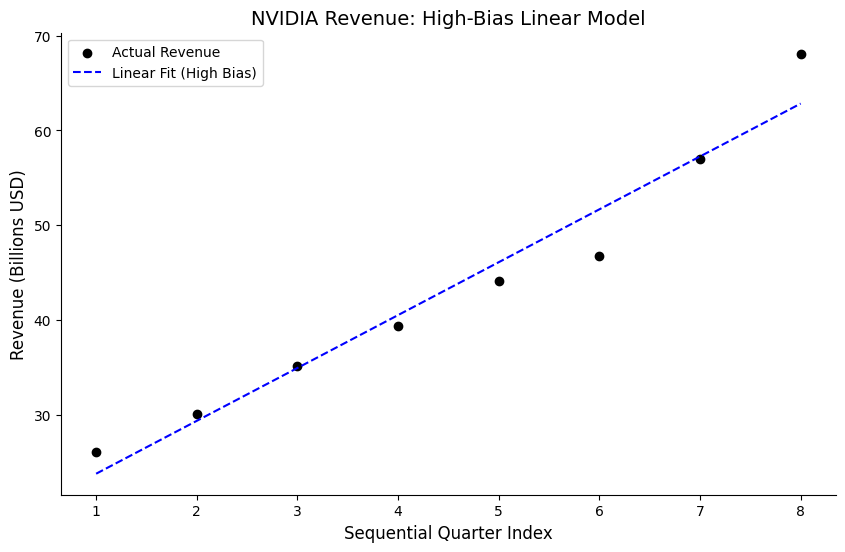

In [3]:
# Step 2: High Bias (Underfitting) Linear Model
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_linear = lin_reg.predict(X)
mse_linear = mean_squared_error(y, y_pred_linear)

print(f"Linear Training MSE (High Bias): {mse_linear:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.plot(X, y_pred_linear, color='blue', linestyle='--', label='Linear Fit (High Bias)')
plt.title('NVIDIA Revenue: High-Bias Linear Model', fontsize=14)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.show()

Polynomial Degree-7 Training MSE (High Variance): 0.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


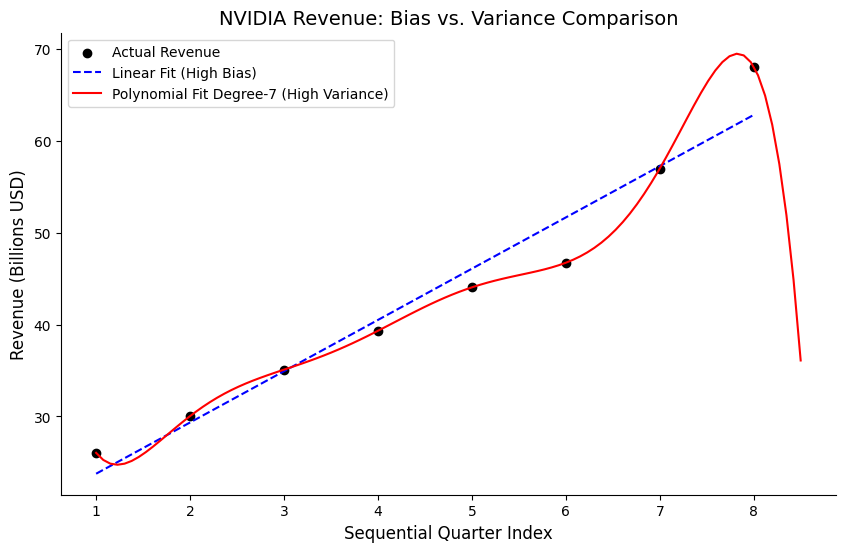

In [4]:
# Step 3: High Variance (Overfitting) Polynomial Model
poly_features = PolynomialFeatures(degree=7, include_bias=False)
X_poly = poly_features.fit_transform(X)

poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred_poly = poly_reg.predict(X_poly)
mse_poly = mean_squared_error(y, y_pred_poly)

print(f"Polynomial Degree-7 Training MSE (High Variance): {mse_poly:.2f}")

# Plotting the smooth polynomial curve
X_smooth = np.linspace(1, 8.5, 100).reshape(-1, 1)
X_smooth_poly = poly_features.transform(X_smooth)
y_smooth_poly = poly_reg.predict(X_smooth_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', label='Actual Revenue')
plt.plot(X, y_pred_linear, color='blue', linestyle='--', label='Linear Fit (High Bias)')
plt.plot(X_smooth, y_smooth_poly, color='red', label='Polynomial Fit Degree-7 (High Variance)')
plt.title('NVIDIA Revenue: Bias vs. Variance Comparison', fontsize=14)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.show()

Hallucinated Q1 FY27 Revenue Prediction: $-84.00 Billion


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


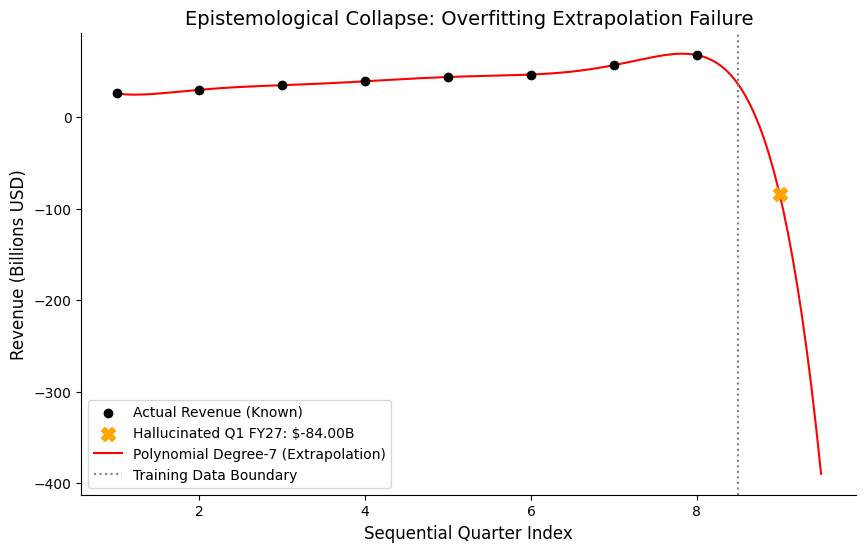

In [5]:
# Step 4: The Extrapolation Collapse
X_future = np.array([[9]])  # Forecasting Q1 FY27
X_future_poly = poly_features.transform(X_future)
future_pred = poly_reg.predict(X_future_poly)

print(f"Hallucinated Q1 FY27 Revenue Prediction: ${future_pred[0]:.2f} Billion")

# Visualize the collapse
X_extrap = np.linspace(1, 9.5, 150).reshape(-1, 1)
X_extrap_poly = poly_features.transform(X_extrap)
y_extrap_poly = poly_reg.predict(X_extrap_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', zorder=5, label='Actual Revenue (Known)')
plt.scatter(X_future, future_pred, color='orange', zorder=5, s=100, marker='X', label=f'Hallucinated Q1 FY27: ${future_pred[0]:.2f}B')
plt.plot(X_extrap, y_extrap_poly, color='red', linestyle='-', label='Polynomial Degree-7 (Extrapolation)')
plt.axvline(x=8.5, color='gray', linestyle=':', linewidth=1.5, label='Training Data Boundary')
plt.title('Epistemological Collapse: Overfitting Extrapolation Failure', fontsize=14)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.show()

In [6]:
# Step 5: K-Fold Cross Validation
cv_scores = cross_val_score(poly_reg, X_poly, y, cv=4, scoring='neg_mean_squared_error')
mean_cv_mse = -cv_scores.mean()

print(f"Linear Training MSE (High Bias):                  {mse_linear:.2f}")
print(f"Polynomial Degree-7 Training MSE (High Variance): {mse_poly:.4f}")
print(f"K-Fold Cross-Validated MSE (True Operational Error): {mean_cv_mse:.2f}")
print(f"\nVariance Gap (CV MSE / Training MSE): {mean_cv_mse / (mse_poly + 1e-9):.0f}x")

Linear Training MSE (High Bias):                  7.91
Polynomial Degree-7 Training MSE (High Variance): 0.0000
K-Fold Cross-Validated MSE (True Operational Error): 8641.58

Variance Gap (CV MSE / Training MSE): 8641551813198x


In [8]:
#AI Expansion

from sklearn.linear_model import RidgeCV

# Define a grid of alpha (penalty) values to search over
# A higher alpha = stronger regularization = more coefficient shrinkage
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

# RidgeCV automatically selects the best alpha via cross-validation
# cv=4 means 4-Fold Cross-Validation
ridge_cv = RidgeCV(alphas=alphas, cv=4, scoring='neg_mean_squared_error')
ridge_cv.fit(X_poly, y)

# The L2 penalty shrinks all coefficients toward zero,
# suppressing the wild oscillations of the degree-7 polynomial
print(f"Optimal Alpha (L2 Penalty): {ridge_cv.alpha_}")
print(f"Ridge Coefficient Magnitudes: {np.round(ridge_cv.coef_, 4)}")

# Generate regularized predictions
y_pred_ridge = ridge_cv.predict(X_poly)
mse_ridge_train = mean_squared_error(y, y_pred_ridge)
print(f"\nRidge Training MSE:           {mse_ridge_train:.2f}")

# Cross-validate the ridge model to get the true operational error
ridge_cv_scores = cross_val_score(ridge_cv, X_poly, y, cv=4, scoring='neg_mean_squared_error')
mean_ridge_cv_mse = -ridge_cv_scores.mean()
print(f"Ridge K-Fold CV MSE (True Operational Error): {mean_ridge_cv_mse:.2f}")

# --- Comparison Summary ---
print("\n--- Model Comparison ---")
print(f"Overfit Poly  | Train MSE: {mse_poly:.4f} | CV MSE: {mean_cv_mse:.2f}")
print(f"Ridge Reg     | Train MSE: {mse_ridge_train:.2f} | CV MSE: {mean_ridge_cv_mse:.2f}")

Optimal Alpha (L2 Penalty): 10.0
Ridge Coefficient Magnitudes: [ 0.0475  0.1269  0.2306  0.2493 -0.1261  0.0189 -0.0009]

Ridge Training MSE:           0.24
Ridge K-Fold CV MSE (True Operational Error): 4323.50

--- Model Comparison ---
Overfit Poly  | Train MSE: 0.0000 | CV MSE: 8641.58
Ridge Reg     | Train MSE: 0.24 | CV MSE: 4323.50


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


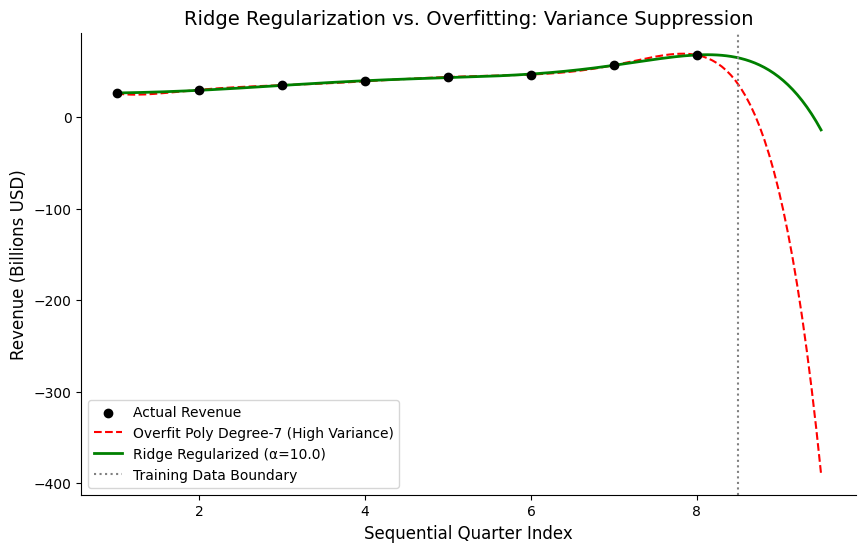

In [9]:
# Plot Ridge vs Overfit comparison
X_extrap = np.linspace(1, 9.5, 150).reshape(-1, 1)
X_extrap_poly = poly_features.transform(X_extrap)

y_extrap_overfit = poly_reg.predict(X_extrap_poly)
y_extrap_ridge = ridge_cv.predict(X_extrap_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='black', zorder=5, label='Actual Revenue')
plt.plot(X_extrap, y_extrap_overfit, color='red', linestyle='--', label='Overfit Poly Degree-7 (High Variance)')
plt.plot(X_extrap, y_extrap_ridge, color='green', linewidth=2, label=f'Ridge Regularized (α={ridge_cv.alpha_})')
plt.axvline(x=8.5, color='gray', linestyle=':', linewidth=1.5, label='Training Data Boundary')
plt.title('Ridge Regularization vs. Overfitting: Variance Suppression', fontsize=14)
plt.xlabel('Sequential Quarter Index', fontsize=12)
plt.ylabel('Revenue (Billions USD)', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()
plt.show()